In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import warnings
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

In [2]:
df = sns.load_dataset("titanic")
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [4]:
df.drop(columns=['embarked', 'class', 'who', 'adult_male', 'deck', 'alive'],axis = 1,inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    object 
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embark_town  889 non-null    object 
 8   alone        891 non-null    bool   
dtypes: bool(1), float64(2), int64(4), object(2)
memory usage: 56.7+ KB


In [5]:
df['age'].fillna(df['age'].mean(), inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    object 
 3   age          891 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embark_town  889 non-null    object 
 8   alone        891 non-null    bool   
dtypes: bool(1), float64(2), int64(4), object(2)
memory usage: 56.7+ KB


In [6]:
df.dropna(subset='embark_town', inplace=True)

In [7]:
from sklearn.preprocessing import LabelEncoder
encode = LabelEncoder()

In [8]:
df['sex'] = encode.fit_transform(df['sex'])
df['embark_town'] = encode.fit_transform(df['embark_town'])

In [9]:
df = df.astype(int)

In [10]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embark_town,alone
0,0,3,1,22,1,0,7,2,0
1,1,1,0,38,1,0,71,0,0
2,1,3,0,26,0,0,7,2,1
3,1,1,0,35,1,0,53,2,0
4,0,3,1,35,0,0,8,2,1


In [11]:
X = df.drop(columns='survived', axis=1)
y = df['survived']

In [12]:
from sklearn.model_selection import train_test_split

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [14]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train.head()

,pclass,sex,age,sibsp,parch,fare,embark_town,alone
708,1,0,22,0,0,151,2,1
240,3,0,29,1,0,14,0,0
382,3,1,32,0,0,7,2,1
792,3,0,29,8,2,69,2,0
683,3,1,14,5,2,46,2,0


In [15]:
X_cols = X_train.columns
# X_train[X_cols] = scaler.fit_transform(X_train[X_cols])
# X_test[X_cols] = scaler.fit_transform(X_test[X_cols])
X_train.head()

,pclass,sex,age,sibsp,parch,fare,embark_town,alone
708,1,0,22,0,0,151,2,1
240,3,0,29,1,0,14,0,0
382,3,1,32,0,0,7,2,1
792,3,0,29,8,2,69,2,0
683,3,1,14,5,2,46,2,0


In [16]:
from sklearn.naive_bayes import GaussianNB
model_NB = GaussianNB()

In [17]:
model_NB.fit(X_train, y_train)

,priors,None
,var_smoothing,1e-09


In [18]:
y_pred = model_NB.predict(X_test)

In [19]:
from sklearn.metrics import classification_report

print(classification_report(y_true=y_test, y_pred=y_pred))

              precision    recall  f1-score   support

           0       0.85      0.77      0.81       109
           1       0.68      0.78      0.73        69

    accuracy                           0.78       178
   macro avg       0.77      0.78      0.77       178
weighted avg       0.78      0.78      0.78       178



In [20]:
#Now Naive Bayes with Laplacian Correction
from sklearn.naive_bayes import MultinomialNB
model_2 = MultinomialNB()

In [21]:
model_2.fit(X_train, y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [22]:
y_pred_MB = model_2.predict(X_test)

In [23]:
print(classification_report(y_test, y_pred_MB))

              precision    recall  f1-score   support

           0       0.72      0.82      0.77       109
           1       0.64      0.51      0.56        69

    accuracy                           0.70       178
   macro avg       0.68      0.66      0.67       178
weighted avg       0.69      0.70      0.69       178



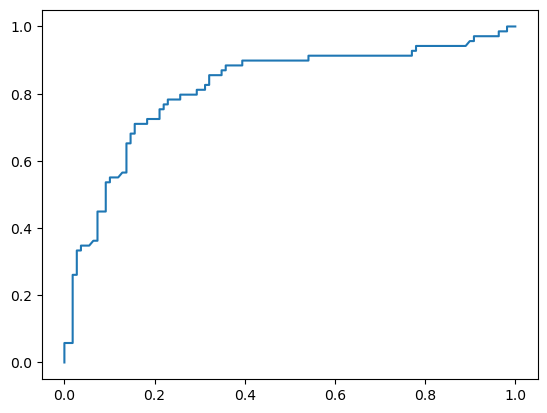

In [25]:
from sklearn.metrics import auc, roc_curve
y_prob = model_NB.predict_proba(X_test)[:,1]

fpr, tpr, thresh = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr)

In [26]:
auc(fpr, tpr)

0.8168461640739262